# 📊 Statistical Lab: Sampling Distributions for Variance
### Chi-Squared Distribution · F-Distribution · Analysis of Variance (ANOVA)

---

> **Lab Objectives:**  
> By the end of this lab, you will be able to:
> - Understand and simulate the Chi-Squared distribution and its role in variance inference
> - Understand and apply the F-Distribution for comparing two variances
> - Perform and interpret One-Way ANOVA to compare means across multiple groups


---

## ⚙️ Setup: Import Required Libraries

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, f, norm

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

np.random.seed(42)

In [42]:
# Assisting Symbols
chi2_sym = 'χ²'
alpha_sym = 'α'
sigma_sym = 'σ'
sigma2_sym = 'σ²'
s2_sym = 'S²'

---
# Part 1: The Chi-Squared Distribution (χ²)

---

## Background & Theory

**Explain the Chi-Squared distribution:**
- How is it constructed from standard normal variables?
- What are its key parameters?
- What is its role in statistical inference for variance?

Write the mathematical relationship between the sample variance $S^2$ and the Chi-Squared statistic, assuming a normal population with true variance $\sigma^2$.

### Theory

**Construction:**  
If $Z_1, Z_2, \ldots, Z_k$ are independent standard normal variables $Z_i \sim N(0,1)$, then:
$$\chi^2_k = \sum_{i=1}^{k} Z_i^2 \sim \chi^2(k)$$
where $k$ is the **degrees of freedom** — the only parameter of the distribution.

**Key Properties:**

| Property | Value |
|---|---|
| Support | $[0, \infty)$ |
| Mean | $k$ |
| Variance | $2k$ |
| Shape | Right-skewed (approaches normal as $k \to \infty$) |
<!-- | Additive | If $X \sim \chi^2(m)$ and $Y \sim \chi^2(n)$ independently, then $X+Y \sim \chi^2(m+n)$ | -->

**Inference for Variance:**  
If $X_1, X_2, \ldots, X_n \overset{iid}{\sim} N(\mu, \sigma^2)$, then the **sample variance** $S^2 = \frac{1}{n-1}\sum_{i=1}^n(X_i - \bar{X})^2$ satisfies:

$$\boxed{\frac{(n-1)S^2}{\sigma^2} \sim \chi^2(n-1)}$$

This pivotal relationship allows us to:
1. Test hypotheses about $\sigma^2$ (Chi-Squared test)
2. Construct confidence intervals for $\sigma^2$

---
## 📌 Task 1.1 — Plot Chi-Squared PDFs for Different Degrees of Freedom

Plot the probability density function (PDF) of the Chi-Squared distribution for degrees of freedom $k = 1, 2, 3, 5, 10, 20$.  
Observe how the shape changes as $k$ increases. What happens to skewness as $k \to \infty$?

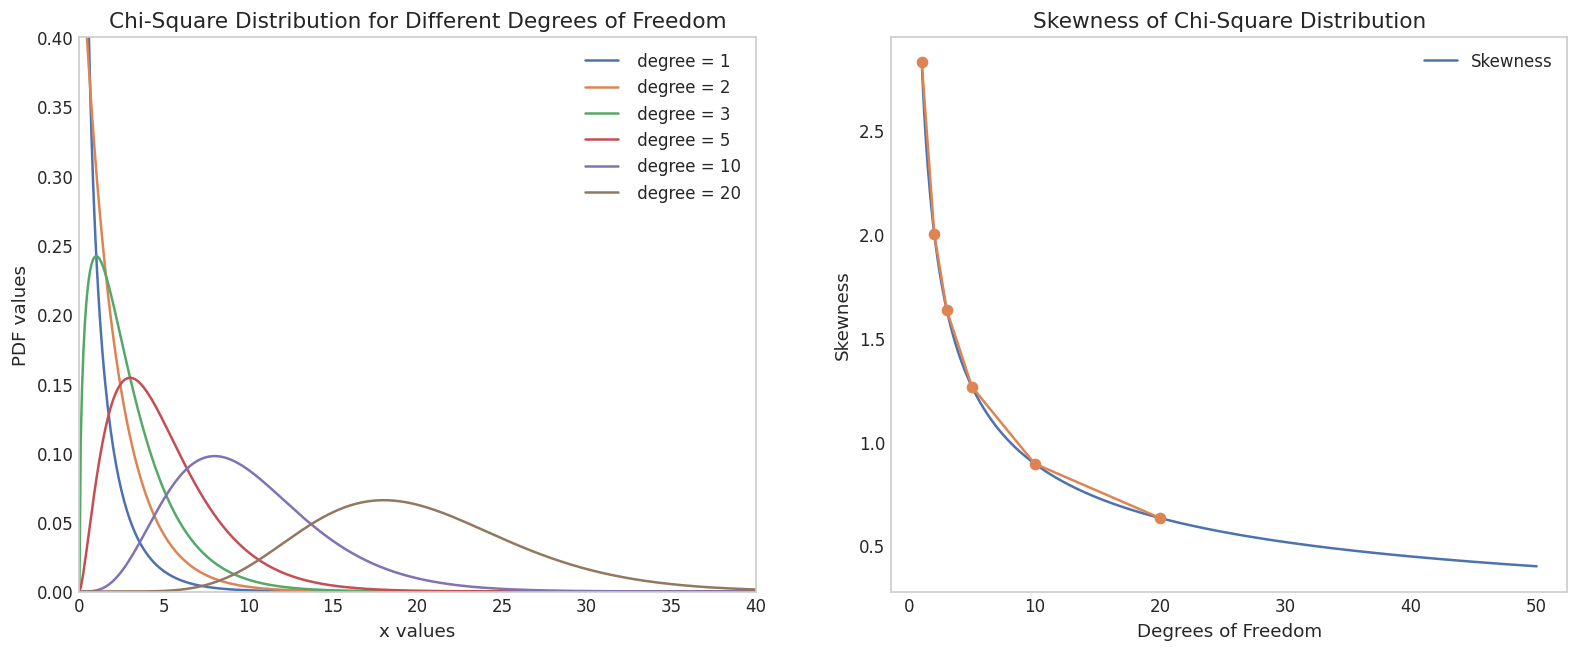

In [43]:
k = [1, 2, 3, 5, 10, 20]
n = np.linspace(0, 40,  500)


fig , ax = plt.subplots(1, 2, figsize=(16, 6))
for degree in k:
    y = chi2.pdf(n, degree)
    ax[0].plot(n, y, label = f" degree = {degree}")
ax[0].set_title(f"Chi-Square Distribution for Different Degrees of Freedom")
ax[0].set_xlabel("x values")
ax[0].set_ylabel("PDF values")
ax[0].legend()
ax[0].set_xlim(0, 40)
ax[0].set_ylim(0, 0.4)
ax[0].grid()

k_cont = np.linspace(1, 50, 500)
skewness = np.sqrt(8 / k_cont)
k_dots = np.array(k)
skewness_dots = np.sqrt(8 / k_dots)

ax[1].plot(k_cont, skewness, 
           label='Skewness')

ax[1].plot(k_dots, skewness_dots, 
           marker='o', linestyle=None)
ax[1].set_title("Skewness of Chi-Square Distribution")
ax[1].set_xlabel("Degrees of Freedom")
ax[1].set_ylabel("Skewness")
ax[1].legend()
ax[1].grid()
plt.show()

---
## 📌 Task 1.2 — Simulating the Sampling Distribution of S²

Draw 10,000 random samples of size $n = 15$ from a $N(50, 100)$ population (i.e., $\mu = 50$, $\sigma^2 = 100$).  
For each sample, compute $S^2$ and the statistic $\chi^2 = \frac{(n-1)S^2}{\sigma^2}$.  
Overlay the theoretical $\chi^2(n-1)$ distribution. Do they match?


*📒Note:*

We know that $\frac{(n-1)S^2}{\sigma^2} \sim \chi^2(n-1)$, which means:

$$S^2 = \frac{\sigma^2}{n-1} \cdot \chi^2(n-1)$$

So $S^2$ is a **scaled chi-squared** random variable with scale factor $\text{scale} = \frac{\sigma^2}{n-1}$.

To get the PDF of a scaled random variable, we use the change-of-variables rule:

$$f_{S^2}(x) = \frac{1}{\text{scale}} \cdot f_{\chi^2}\!\left(\frac{x}{\text{scale}}\right)$$


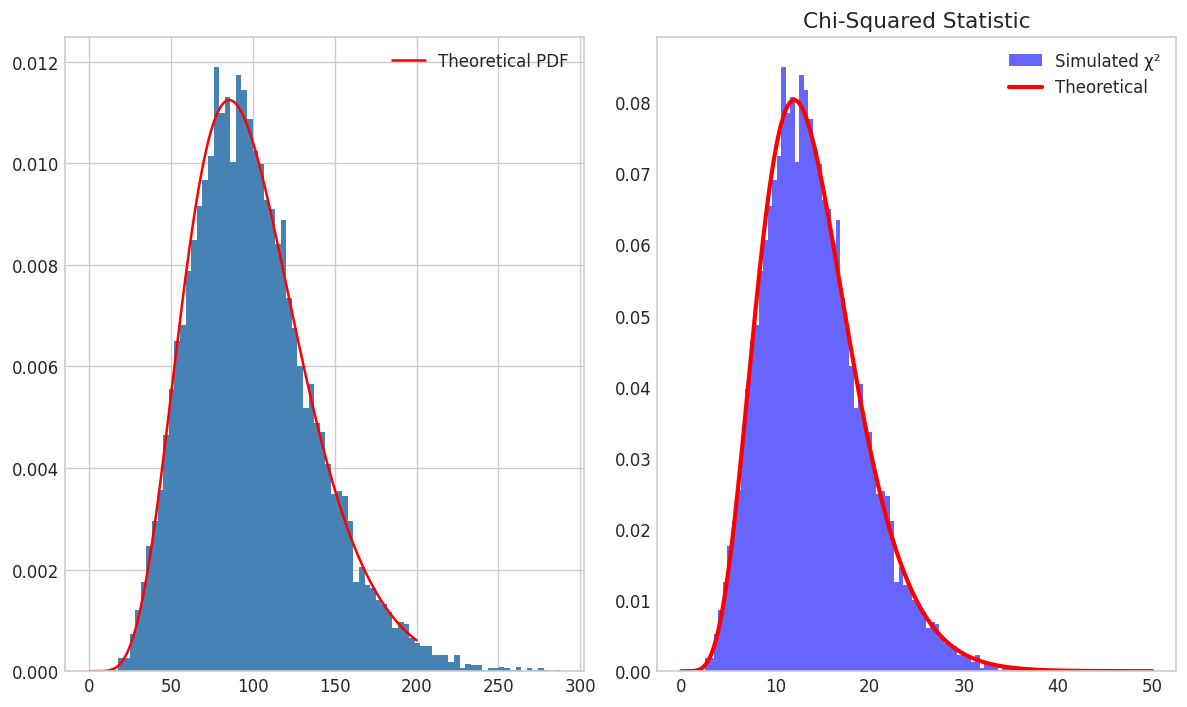

Sample Variance Mean: 100.02
Sample Variance Theoretical Mean: 100.00
Chi-Squared Mean: 14.00
Chi-Squared Theoretical Variance: 14.00
Chi-Squared Simulated Variance: 27.71


In [44]:
n = 15
simulations = 10000
mean = 50
variance = 100
std = np.sqrt(variance)
degree_of_freedom = n - 1

samples = np.random.normal(loc=mean, scale=std, size=(simulations, n))
sample_variances = np.var(samples, axis=1, ddof=1)
chi2_simulated = degree_of_freedom * sample_variances / variance

figsize, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].hist(sample_variances, bins=80, density=True, color='steelblue')

x_s2 = np.linspace(0, 200, 500)
scale = variance / degree_of_freedom
y_s2_theoretical = chi2.pdf(x_s2 / scale, degree_of_freedom) * (1 / scale)
ax[0].plot(x_s2, y_s2_theoretical, color='r', label='Theoretical PDF')
ax[0].legend()

ax[1].hist(chi2_simulated, bins=80, density=True, alpha=0.6, color='b', label='Simulated χ²')
x_chi2 = np.linspace(0, 50, 500)
y_chi2_theo = chi2.pdf(x_chi2, degree_of_freedom)
ax[1].plot(x_chi2, y_chi2_theo, color='red', linewidth=2.5, label='Theoretical')
ax[1].set_title('Chi-Squared Statistic')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

print(f"Sample Variance Mean: {np.mean(sample_variances):.2f}")
print(f"Sample Variance Theoretical Mean: {variance:.2f}")
print(f"Chi-Squared Mean: {np.mean(chi2_simulated):.2f}")
print(f"Chi-Squared Theoretical Variance: {degree_of_freedom:.2f}")
print(f"Chi-Squared Simulated Variance: {np.var(chi2_simulated):.2f}")

---
## 📌 Task 1.3 — Confidence Interval for σ² Using Chi-Squared

A quality-control engineer measures the fill volume of 20 bottles and obtains a sample variance $S^2 = 0.35$ mL².  
Assuming the fill volumes are normally distributed, construct a **95% confidence interval** for the population variance $\sigma^2$.  

The CI formula is:
$$\left(\frac{(n-1)S^2}{\chi^2_{\alpha/2}}, \; \frac{(n-1)S^2}{\chi^2_{1-\alpha/2}}\right)$$

n=20, s2 = 0.35, df=19, alpha=0.05 (95% CI)
 x2_0.025 = 8.9065, x2_0.975 = 32.8523
Confidence Interval for Variance: [0.2024, 0.7466]
Confidence Interval for Standard Deviation: [0.4499, 0.8641]


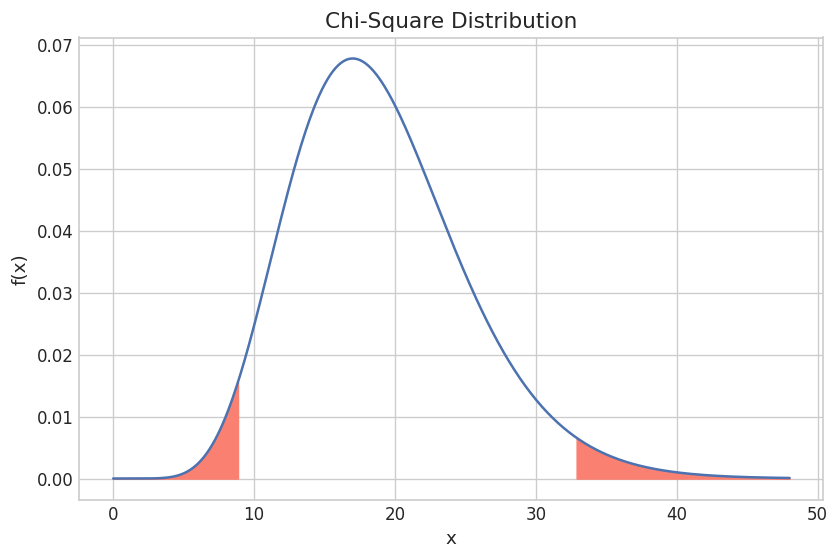

In [45]:
n = 20
s2 = 0.35
df = n-1
alpha = 0.05

chi2_lower = chi2.ppf(alpha/2, df)
chi2_upper = chi2.ppf(1 - alpha/2, df)

ci_lower_var = (df * s2) / chi2_upper
ci_upper_var = (df * s2) / chi2_lower

ci_lower_std = np.sqrt(ci_lower_var)
ci_upper_std = np.sqrt(ci_upper_var)

print(f"n={n}, s2 = {s2:.2f}, df={df}, alpha={alpha} (95% CI)\n x2_0.025 = {chi2_lower:.4f}, x2_0.975 = {chi2_upper:.4f}")
print(f"Confidence Interval for Variance: [{ci_lower_var:.4f}, {ci_upper_var:.4f}]")
print(f"Confidence Interval for Standard Deviation: [{ci_lower_std:.4f}, {ci_upper_std:.4f}]")
plt.figure(figsize=(8, 5))
x = np.linspace(0, 48, 500)
y = chi2.pdf(x, df)
plt.plot(x, y)
mask_left_tail = x <= chi2_lower
mask_middle = (x > chi2_lower) & (x < chi2_upper)
mask_right_tail = x >= chi2_upper
plt.fill_between(x[mask_left_tail], 0, y[mask_left_tail], color='salmon')
plt.fill_between(x[mask_right_tail], 0, y[mask_right_tail], color='salmon')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Chi-Square Distribution')
plt.show()


---
# Part 2: The F-Distribution

---

## Theory of the F-Distribution

Define the F-Distribution. Show how it arises as the ratio of two independent Chi-Squared variables.  
State the key parameters and properties, and explain its primary use in statistics.

### Theory

**Definition:**  
If $U \sim \chi^2(d_1)$ and $V \sim \chi^2(d_2)$ are **independent**, then:
$$F = \frac{U/d_1}{V/d_2} \sim F(d_1, d_2)$$

**Application to Variance Comparison:**  
Given two independent normal populations:
- $X_1, \ldots, X_{n_1} \sim N(\mu_1, \sigma_1^2)$
- $Y_1, \ldots, Y_{n_2} \sim N(\mu_2, \sigma_2^2)$

The test statistic for $H_0: \sigma_1^2 = \sigma_2^2$ is:
$$\boxed{F = \frac{S_1^2 / \sigma_1^2}{S_2^2 / \sigma_2^2} \overset{H_0}{=} \frac{S_1^2}{S_2^2} \sim F(n_1-1,\; n_2-1)}$$

**Key Properties:**

| Property | Value |
|---|---|
| Parameters | $d_1$ (numerator df), $d_2$ (denominator df) |
| Support | $(0, \infty)$ |
| Mean | $\frac{d_2}{d_2-2}$ for $d_2 > 2$ |
| Reciprocal | If $F \sim F(d_1, d_2)$ then $1/F \sim F(d_2, d_1)$ |
<!-- | Relation to t | If $T \sim t(\nu)$, then $T^2 \sim F(1, \nu)$ | -->

**Main Uses:**
1. Testing equality of two variances (Levene's test, F-test)
2. ANOVA: comparing means of multiple groups

---
## 📌 Task 2.1 — Visualize F-Distribution PDFs

Plot the F-distribution PDF for several combinations of degrees of freedom:  
$(d_1, d_2) \in \{(1,1), (2,5), (5,10), (10,20), (30,50)\}$.  
Describe how the shape changes as both $d_1$ and $d_2$ grow.

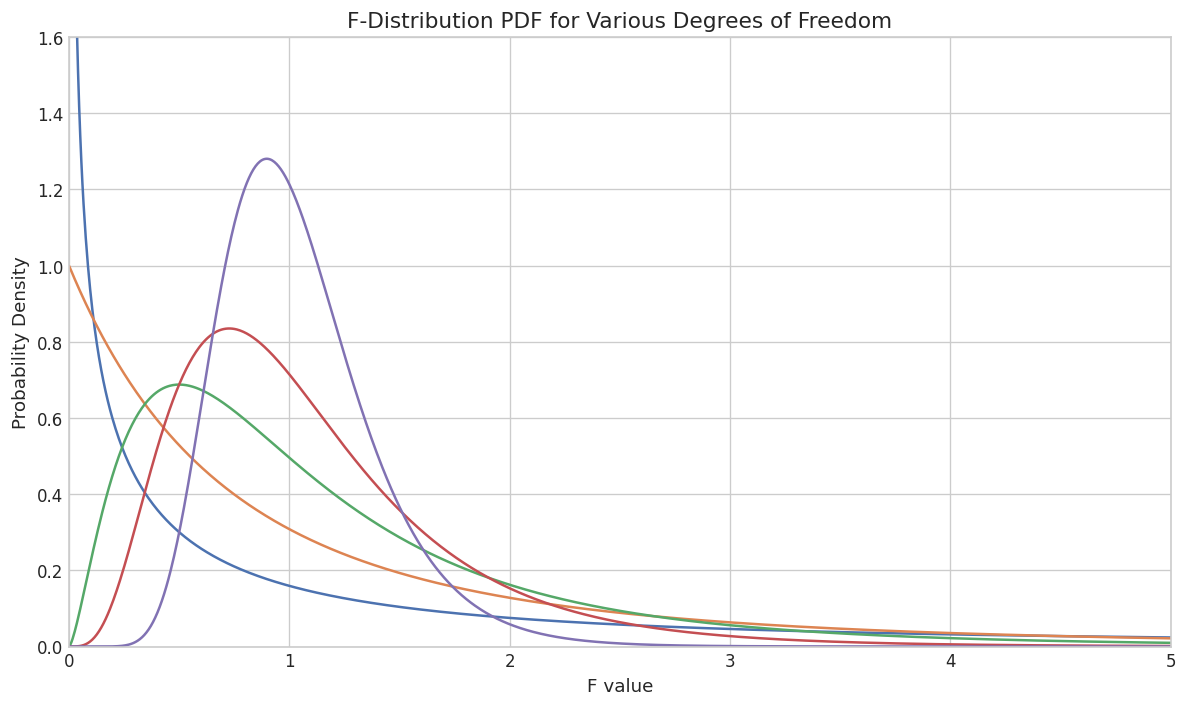

In [46]:
# --- Answer 2.1 ---
df_pairs = [(1,1), (2,5), (5, 10), (10, 20), (30, 50)]
x = np.linspace(0.001, 5, 1000)
plt.figure(figsize=(10, 6))

for i , (d1, d2) in enumerate(df_pairs):
	y = f.pdf(x, d1, d2)
	plt.plot(x, y, label = f"df1 = {d1}, df2 = {d2}")
plt.title('F-Distribution PDF for Various Degrees of Freedom')
plt.xlabel('F value')
plt.ylabel('Probability Density')
plt.xlim(0, 5)
plt.ylim(0, 1.6)
plt.tight_layout()
plt.show()


---
## 📌 Task 2.2 — Two-Sample F-Test for Equality of Variances

A researcher measures reaction times (ms) of two groups: Group A uses a new UI design, Group B uses the old design.

```
Group A: [210, 225, 198, 232, 215, 208, 221, 234, 219, 212, 228, 205]
Group B: [245, 260, 230, 275, 250, 240, 265, 280, 255, 248, 272, 258, 263, 270]
```

Test at $\alpha = 0.05$ whether the two groups have equal variances ($H_0: \sigma_A^2 = \sigma_B^2$).

*Note:*

Two-Tailed P-Value Calculation
>    ```python
>    p_value = 2 * min(f.cdf(F_stat, df1, df2), f.sf(F_stat, df1, df2))
>    ```

```
     chi2.pdf()  → "Given x, what's the density?"
     chi2.cdf()  → "Given x, what's P(X ≤ x)?"
     chi2.ppf()  → "Given a probability p, what x gives P(X ≤ x) = p?"  ← INVERSE
     chi2.sf()   → "Given x, what's P(X > x)?" (survival function = 1 - CDF)
```

Sample Variance A: 125.6591
Sample Variance B: 203.1484
Degrees of Freedom:df1: 11, df2 = 13
F-Statistic: 0.6186
P-Value: 0.4314

Test at alpha = 0.05:
Fail to reject H0: No evidence that var is different.


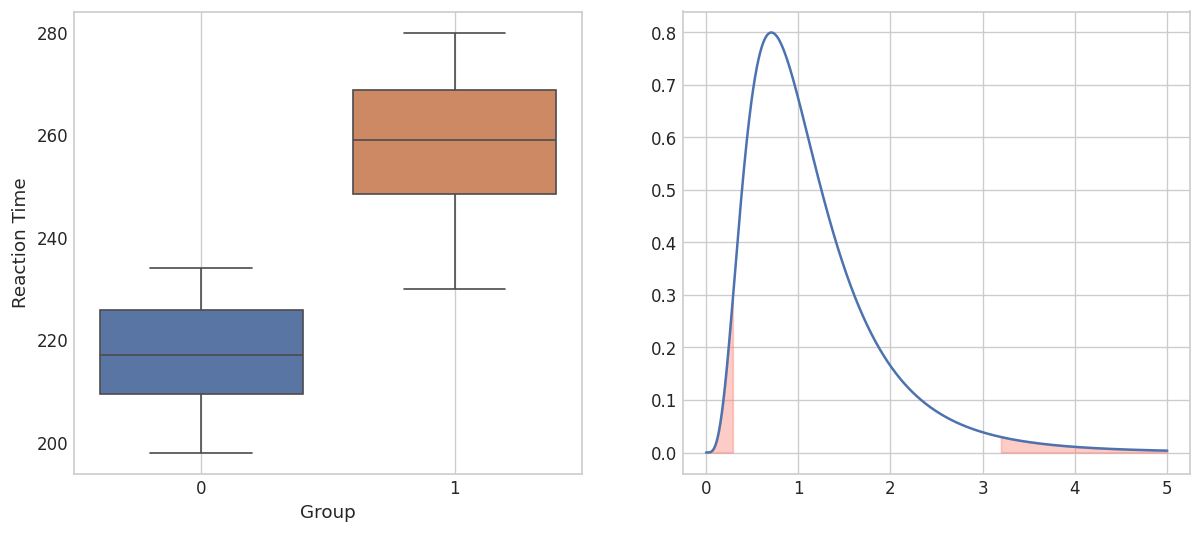

In [47]:
GroupA = [210, 225, 198, 232, 215, 208, 221, 234, 219, 212, 228, 205]
GroupB = [245, 260, 230, 275, 250, 240, 265, 280, 255, 248, 272, 258, 263, 270]
alpha = 0.05
var_A = np.var(GroupA, ddof=1)
var_B = np.var(GroupB, ddof=1)

df1 = len(GroupA) - 1
df2 = len(GroupB) - 1
f_stat = var_A / var_B
p_val = 2 * min(f.cdf(f_stat, df1, df2), f.sf(f_stat, df1, df2))
print(f"Sample Variance A: {var_A:.4f}")
print(f"Sample Variance B: {var_B:.4f}")
print(f"Degrees of Freedom:df1: {df1}, df2 = {df2}")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val:.4f}")
print()

alpha = 0.05
print(f"Test at alpha = {alpha}:")
if p_val < alpha:
    print("Reject H0: Variance of 2 groups are different.")
else:
    print("Fail to reject H0: No evidence that var is different.")
    
fig, ax = plt.subplots(1, 2, figsize=(12, 5))  
sns.boxplot(data=[GroupA, GroupB], ax=ax[0])
ax[0].set_xlabel('Group')
ax[0].set_ylabel('Reaction Time')
ax[0].grid()

x = np.linspace(0.001, 5, 1000)
y = f.pdf(x, df1, df2)
ax[1].plot(x, y)
f_lower_crit = f.ppf(alpha / 2, df1, df2)
f_upper_crit = f.ppf(1 - alpha / 2, df1, df2)
mask_left_tail = x <= f_lower_crit
mask_right_tail = x >= f_upper_crit
ax[1].fill_between(x[mask_left_tail], 0, y[mask_left_tail], color='salmon', alpha=0.4, label='Rejection region')
ax[1].fill_between(x[mask_right_tail], 0, y[mask_right_tail], color='salmon', alpha=0.4)
plt.show()

---
# Part 3: Analysis of Variance (ANOVA)

---

## ANOVA Theory

State the assumptions, hypotheses, and logic of One-Way ANOVA.  
Define **SST**, **SSW** (SSE), and **SSB** (SSA), and show the fundamental identity:
$$SS_{\text{Total}} = SS_{\text{Between}} + SS_{\text{Within}}$$

Define the Mean Squares and the F-statistic used in ANOVA.

### ANOVA Theory

**Assumptions:**
1. **Independence**: Observations are independent within and across groups
2. **Normality**: Each group follows a normal distribution
3. **Homoscedasticity**: All groups have equal variances $\sigma_1^2 = \sigma_2^2 = \cdots = \sigma_k^2 = \sigma^2$

**Hypotheses:**
$$H_0: \mu_1 = \mu_2 = \cdots = \mu_k \qquad \text{vs} \qquad H_1: \text{at least one mean differs}$$

**Sum of Squares Decomposition:**

Let $x_{ij}$ = $j$-th observation in group $i$, $\bar{x}_i$ = group mean, $\bar{x}$ = grand mean, $n_i$ = group size, $N$ = total observations.

| Source | Formula | df |
|---|---|---|
| $SS_{\text{Between}}$ (groups) | $\sum_i n_i(\bar{x}_i - \bar{x})^2$ | $k-1$ |
| $SS_{\text{Within}}$ (error) | $\sum_i \sum_j (x_{ij} - \bar{x}_i)^2$ | $N-k$ |
| $SS_{\text{Total}}$ | $\sum_i \sum_j (x_{ij} - \bar{x})^2$ | $N-1$ |

**Identity:** $\boxed{SS_{\text{Total}} = SS_{\text{Between}} + SS_{\text{Within}}}$

**Mean Squares and F-Statistic:**
$$MS_{\text{Between}} = \frac{SS_{\text{Between}}}{k-1}, \qquad MS_{\text{Within}} = \frac{SS_{\text{Within}}}{N-k}$$

$$\boxed{F = \frac{MS_{\text{Between}}}{MS_{\text{Within}}} \sim F(k-1,\; N-k) \text{ under } H_0}$$

**Intuition:** Under $H_0$, both $MS_B$ and $MS_W$ estimate $\sigma^2$, so $F \approx 1$.  
Under $H_1$, $MS_B$ is inflated by group differences, pushing $F$ into the right tail.

---
## 📌 Task 3.1 — One-Way ANOVA from Scratch

A study tests whether three different fertilizers (A, B, C) produce different crop yields (kg/plot):

```
Fertilizer A: [45, 48, 47, 50, 46, 49, 44, 51]
Fertilizer B: [38, 40, 42, 39, 41, 37, 43, 40]
Fertilizer C: [52, 55, 58, 54, 57, 53, 56, 59]
```

Perform a complete One-Way ANOVA manually (compute all SS, df, MS, F) and verify with `scipy.stats.f_oneway`. Use $\alpha = 0.05$.

In [48]:
from scipy.stats import f, f_oneway

FertilizerA =  [45, 48, 47, 50, 46, 49, 44, 51]
FertilizerB = [38, 40, 42, 39, 41, 37, 43, 40]
FertilizerC = [52, 55, 58, 54, 57, 53, 56, 59]

alpha = 0.05
groups = [FertilizerA, FertilizerB, FertilizerC]
all_data = np.concatenate(groups)
total_mean = np.mean(all_data)
N = len(all_data)
k = len(groups)
ss_between = sum(len(g) * (np.mean(g) - total_mean) ** 2 for g in groups)
ss_within = sum(sum((g - np.mean(g)) ** 2) for g in groups)
df_between = k - 1
df_within = N - k
ms_between = ss_between / df_between
ms_within = ss_within / df_within
f_stat_manual = ms_between / ms_within
p_value_manual = f.sf(f_stat_manual, df_between, df_within)

f_stat_scipy, p_value_scipy = f_oneway(FertilizerA, FertilizerB, FertilizerC)

print(f"Manual ANOVA: F-statistic = {f_stat_manual:.4f}, p-value = {p_value_manual:.4f}")
print(f"Scipy ANOVA: F-statistic = {f_stat_scipy:.4f}, p-value = {p_value_scipy:.4f}")
print(f"between-group|| SS: {ss_between:.4f}, df: {df_between}, MS: {ms_between:.4f}")
print(f"within-group|| SS: {ss_within:.4f}, df: {df_within}, MS: {ms_within:.4f}")
if p_value_manual < alpha:
	print("Reject H0: At least one group mean is different.")
else:
	print("Fail to reject H0: No evidence that group means are different.")

Manual ANOVA: F-statistic = 90.1250, p-value = 0.0000
Scipy ANOVA: F-statistic = 90.1250, p-value = 0.0000
between-group|| SS: 961.3333, df: 2, MS: 480.6667
within-group|| SS: 112.0000, df: 21, MS: 5.3333
Reject H0: At least one group mean is different.


---
## 📌 Task 3.2 — Visualizing the ANOVA Results (Optional)

Create a comprehensive visualization including:
1. A grouped boxplot with individual data points
2. The SS decomposition as a bar chart
3. The F-distribution showing the observed F and critical value

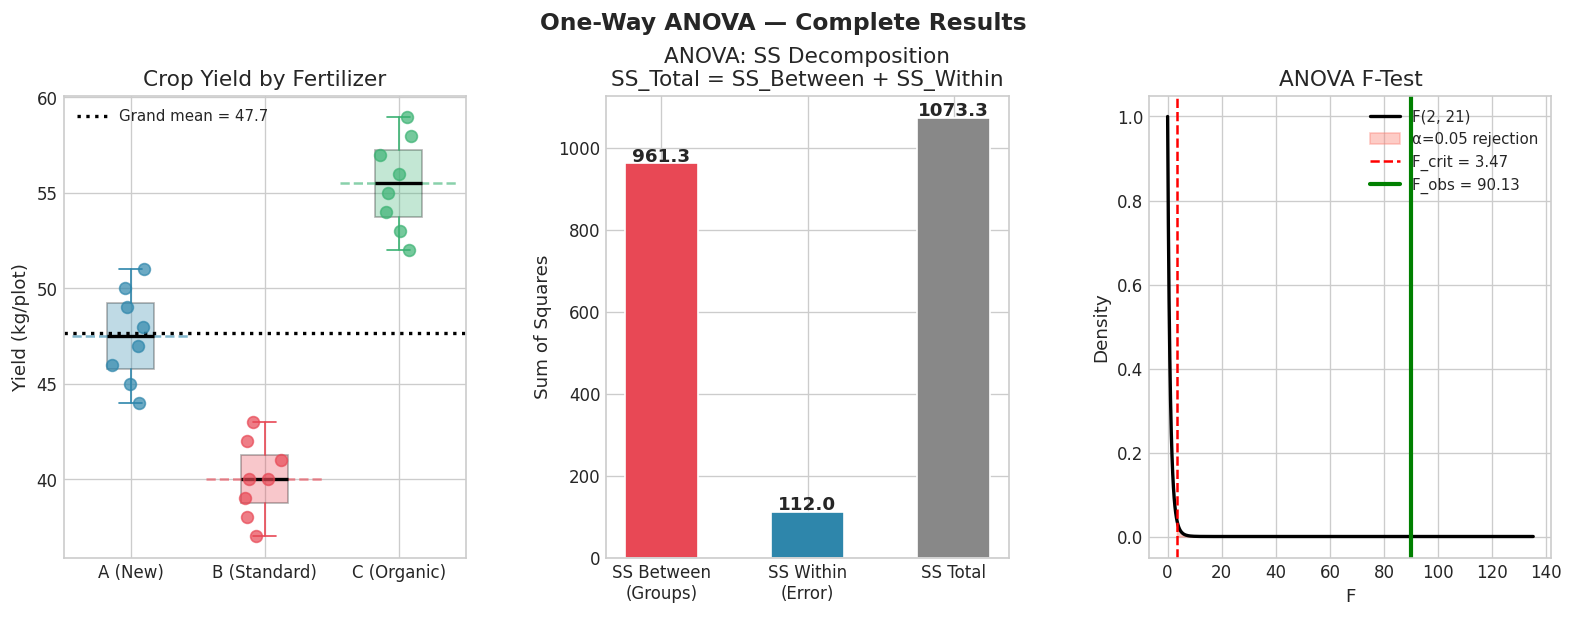

In [ ]:
# --- Answer 3.2 ---

---
# Summary & Key Takeaways

---

| Distribution | Built From | Key Use | Parameter(s) |
|---|---|---|---|
| **Chi-Squared** $\chi^2(k)$ | Sum of $k$ squared standard normals | Testing/estimating $\sigma^2$ | $k$ = degrees of freedom |
| **F-distribution** $F(d_1, d_2)$ | Ratio of two $\chi^2$ / their df | Comparing two variances | $d_1, d_2$ = numerator/denominator df |
| **ANOVA F-test** | $MS_{\text{Between}} / MS_{\text{Within}}$ | Comparing $k \geq 2$ means | $k-1$, $N-k$ df |

**Key Formulas Recap:**

$$\frac{(n-1)S^2}{\sigma^2} \sim \chi^2(n-1) \qquad \frac{S_1^2}{S_2^2} \sim F(n_1-1, n_2-1) \qquad F_{\text{ANOVA}} = \frac{MS_B}{MS_W} \sim F(k-1, N-k)$$


---
*Statistics Lab — Sampling Distributions for Variance*

---

$$Good \space Luck✨$$